# preamble

## Auxilliary

In [ ]:
import os
from exp import runNSave, get_times_file, record_eye, record_fun3

## Config

In [ ]:
path = "."

# rule files
rules_files = [ os.path.join(path, f"rules_red{nr}.n3") for nr in range(0, 2) ]
# datasets
data_files = [ os.path.join(path, "data", f"gen{size}_pt{pt}.n3") for size in [ 100, 200, 500, 700, 1000, 2000, 5000 ] for pt in [ 1, 2] ]
# data_files = [ os.path.join(path, "data", "gen100_pt1.n3") ]

# number of experiment runs
nr_runs = 1

# eye

Run the performance experiments using the eye reasoner.

In [ ]:
times_fh = get_times_file(os.path.join(path, "results"), 'eye')

query_file = os.path.join(path, "query_eye.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
            
            netw_time, reas_time = runNSave(["eye", rules_file, data_file , "--query", query_file, "--nope"], eye_res_file)
            record_eye(times_fh, run, rules_name, data_name, netw_time, reas_time)

            times_fh.flush()
    
times_fh.close()

# fun3

Run the performance experiments using the fun3 reasoner.

In [ ]:
from pathlib import Path
import sys
sys.path.insert(0, "../../")
from n3.to_py import run_py, save_py

In [ ]:
times_fh = get_times_file(os.path.join(path, "results"), 'fun3')

query_file = os.path.join(path, "query.n3")
code_file = os.path.join(path, "results", "code_out.py")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = os.path.basename(rules_file)
            data_name = os.path.basename(data_file)
            
            fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")
        
            # save_py(Path(query_file), Path(rules_file), Path(data_file), code_file, print_code=False, add_tracing=False, code_dir="../../../..")
            netw_time, gen_time, exec_time, reas_time = run_py(Path(query_file), Path(rules_file), Path(data_file), save_to=fun3_res_file)
            record_fun3(times_fh, run, rules_name, data_name, netw_time, reas_time, gen_time, exec_time)
    
        times_fh.flush()
    
times_fh.close()

# compare output

Compare the outputs generated by eye and fun3.

In [24]:
import sys
sys.path.insert(0, "../../")

from n3.parse import parse_n3_file

for rules_file in rules_files:
    print("rules:", rules_file)

    for data_file in data_files:
        print("data:", data_file)
        
        rules_name = os.path.basename(rules_file)
        data_name = os.path.basename(data_file)
        
        eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
        fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")

        model1 = parse_n3_file(eye_res_file).data; label1 = "eye"
        model2 = parse_n3_file(fun3_res_file).data; label2 = "fun3"

        compliant = True
        for t in model1.triples():
            if t not in model2.triples():
                print(f"different in {label1}:")
                print(t)
                compliant = False
                
        for t in model2.triples():
            if t not in model1.triples():
                print(f"different in {label2}:")
                print(t)
                compliant = False
                    
        if compliant:
            print("compliant")
        else:
            print("NON COMPLIANT")

rules: ./rules_red0.n3
data: ./data/gen100_pt1.n3
compliant
data: ./data/gen100_pt2.n3
compliant
data: ./data/gen200_pt1.n3
compliant
data: ./data/gen200_pt2.n3
compliant
data: ./data/gen500_pt1.n3
compliant
data: ./data/gen500_pt2.n3
compliant
data: ./data/gen700_pt1.n3
compliant
data: ./data/gen700_pt2.n3
compliant
data: ./data/gen1000_pt1.n3
compliant
data: ./data/gen1000_pt2.n3
compliant
data: ./data/gen2000_pt1.n3
compliant
data: ./data/gen2000_pt2.n3
compliant
data: ./data/gen5000_pt1.n3
compliant
data: ./data/gen5000_pt2.n3
compliant
rules: ./rules_red1.n3
data: ./data/gen100_pt1.n3
compliant
data: ./data/gen100_pt2.n3
compliant
data: ./data/gen200_pt1.n3
compliant
data: ./data/gen200_pt2.n3
compliant
data: ./data/gen500_pt1.n3
compliant
data: ./data/gen500_pt2.n3
compliant
data: ./data/gen700_pt1.n3
compliant
data: ./data/gen700_pt2.n3
compliant
data: ./data/gen1000_pt1.n3
compliant
data: ./data/gen1000_pt2.n3
compliant
data: ./data/gen2000_pt1.n3
compliant
data: ./data/gen2000

# analyze

Analyze the performance of eye and fun3.

In [25]:
from exp import load_n3_times, load_n3_agg

In [26]:
import matplotlib.pyplot as plt

def plot_query(df_eye, df_fun3, data_label, query_id=None):
    label = f"dataset {data_label}"
    if query_id is not None:
        label = f"ruleset {query_id+1} ({label})"
    plot(label, df_eye, df_fun3)

def plot(name, df_eye, df_fun3):
    fig, ax = plt.subplots()
    ax.set_title(name)

    df_eye.plot(x='data_id', y='total_time', ax=ax, label='eye', xlabel="dataset (# patients)", ylabel="total time(ms)")
    df_fun3.plot(x='data_id', y='total_time', ax=ax, label='fun3', xlabel="dataset (# patients)", ylabel="total time (ms)")

In [27]:
def avg_times(sys,df):
    print(sys)
    print("avg load time:", round(df['netw_time'].mean(), 0))
    print("avg reasoning time:", round(df['reas_time'].mean(), 0))
    if sys == 'fun3':
        print("avg code gen time:", round(df['gen_time'].mean(), 0))
    print("avg total time:", round(df['total_time'].mean(), 0))

## overall

In [28]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"))
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"))

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1427.0
avg reasoning time: 7.0
avg total time: 1434.0
fun3
avg load time: 12.0
avg reasoning time: 2769.0
avg code gen time: 7.0
avg total time: 2781.0


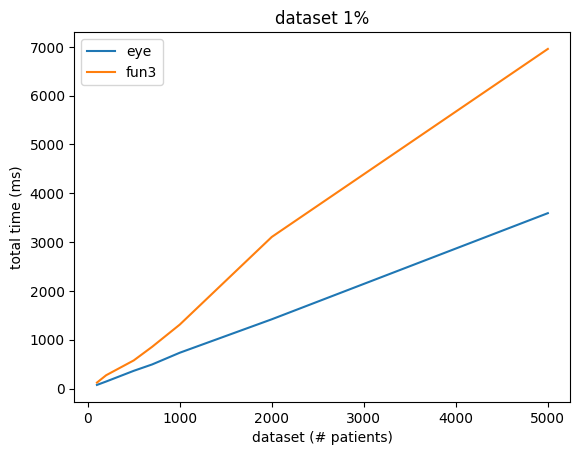

In [29]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1")

plot_query(df_eye, df_fun3, "1%")

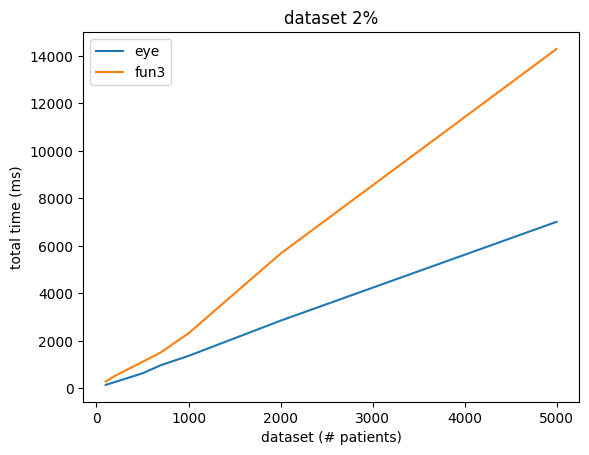

In [30]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2")

plot_query(df_eye, df_fun3, "2%")

## pt1

In [31]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), pt="pt1")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), pt="pt1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 971.0
avg reasoning time: 3.0
avg total time: 974.0
fun3
avg load time: 15.0
avg reasoning time: 1871.0
avg code gen time: 5.0
avg total time: 1886.0


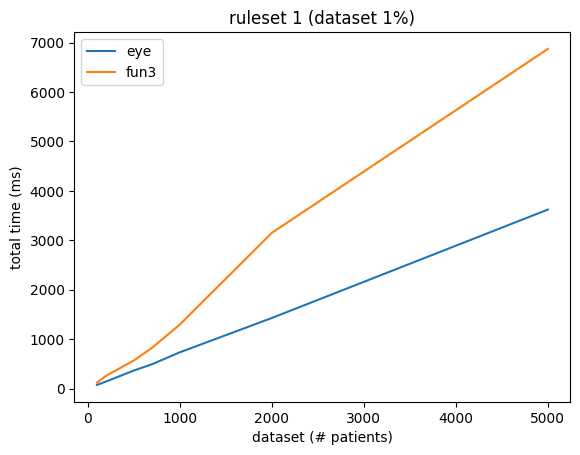

In [32]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="0")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="0")

plot_query(df_eye, df_fun3, "1%", 0)

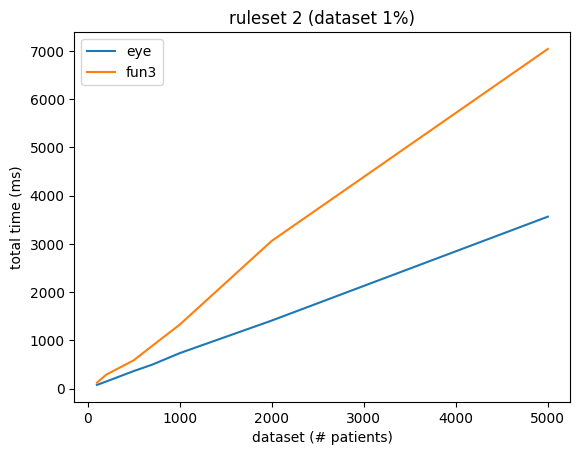

In [33]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="1")

plot_query(df_eye, df_fun3, "1%", 1)

## pt2

In [34]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), "pt2")
df_eye

,data,netw_time,reas_time,total_time,data_id
1,gen100_pt2.n3,144.333333,0.000000,144.333333,100
3,gen200_pt2.n3,266.083333,0.500000,266.583333,200
5,gen500_pt2.n3,631.333333,2.000000,633.333333,500
6,gen700_pt2.n3,973.416667,3.250000,976.666667,700
0,gen1000_pt2.n3,1360.916667,5.500000,1366.416667,1000
2,gen2000_pt2.n3,2835.333333,14.583333,2849.916667,2000
4,gen5000_pt2.n3,6965.083333,49.250000,7014.333333,5000


In [35]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1882.0
avg reasoning time: 11.0
avg total time: 1893.0
fun3
avg load time: 10.0
avg reasoning time: 3666.0
avg code gen time: 8.0
avg total time: 3676.0


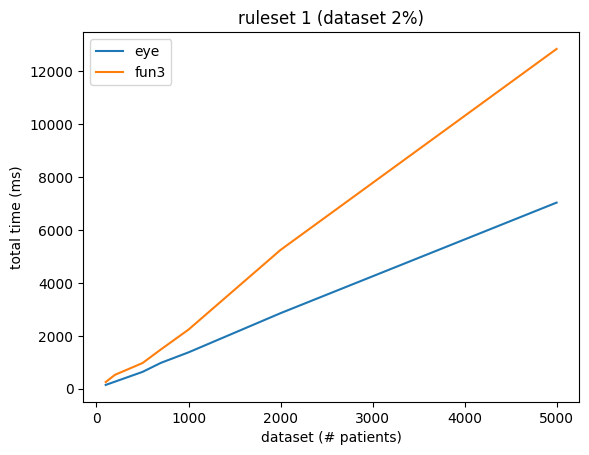

In [36]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="0")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="0")

plot_query(df_eye, df_fun3, "2%", 0)

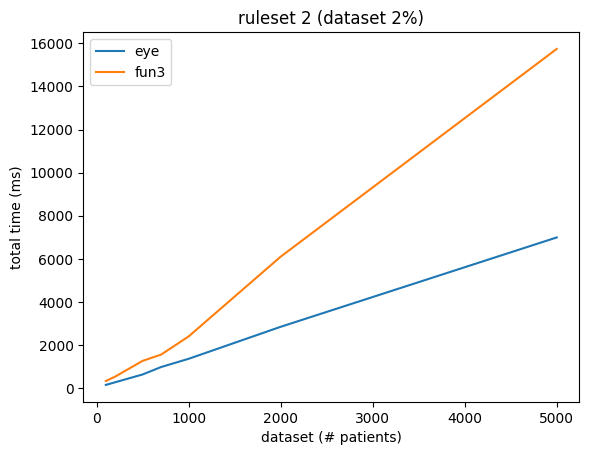

In [37]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1")
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1")

plot_query(df_eye, df_fun3, "2%", 1)

## rule 0

In [38]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="0")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="0")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1432.0
avg reasoning time: 7.0
avg total time: 1438.0
fun3
avg load time: 5.0
avg reasoning time: 2613.0
avg code gen time: 2.0
avg total time: 2617.0


## rule 1

In [39]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="1")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="1")

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1422.0
avg reasoning time: 7.0
avg total time: 1429.0
fun3
avg load time: 20.0
avg reasoning time: 2925.0
avg code gen time: 11.0
avg total time: 2945.0


# sanity check

## consistency across runs

### eye

In [40]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_eye.csv"))
cols = ['netw_time', 'reas_time', 'total_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# eye
# avg load time: 521.0
# avg reasoning time: 2.0
# avg total time: 523.0

,run,netw_time,reas_time,total_time
0,0,1438.767857,6.982143,1445.750000
1,1,1415.035714,6.750000,1421.785714
2,2,1429.964286,6.928571,1436.892857
3,3,1423.678571,6.821429,1430.500000
4,4,1414.714286,6.857143,1421.571429


### fun3

In [41]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"))
cols = ['netw_time', 'reas_time', 'total_time', 'gen_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# fun3
# avg load time: 23.0
# avg reasoning time: 952.0
# avg code gen time: 6.0
# avg total time: 975.0

,run,netw_time,reas_time,total_time,gen_time
0,0,11.571429,2730.375000,2741.946429,4.500000
1,1,14.107143,2795.214286,2809.321429,7.357143
2,2,10.178571,2789.750000,2799.928571,15.250000
3,3,17.142857,2785.785714,2802.928571,3.750000
4,4,9.857143,2780.785714,2790.642857,3.750000
